# **NumPy 선형대수 — 이번 수업용**
## 회귀 풀이 · 고유치 분해

방금 배운 **전치**(`.T`) · **행렬곱**(`@`) · **행렬식**(det) · **역행렬**(inv)이 그대로 쓰이는 두 응용을 한 자리에 모았다.

- **1부 회귀 풀이** — 정규방정식 `β=(XᵀX)⁻¹Xᵀy` 와 Cramer 법칙으로 선형회귀를 직접 푼다.
- **2부 고유치 분해** — 대칭행렬을 `A=QΛQᵀ` 로 분해하고, 큰 고유치 몇 개로 이미지를 압축한다.

두 부 모두 같은 도구를 쓴다. 특히 **직교행렬에서는 역행렬이 전치**(`Q⁻¹=Qᵀ`)라는 점이 1부의 `(XᵀX)⁻¹` 와 2부의 분해를 잇는다.

---

# **1부 · 회귀 풀이**(Regression) — NumPy로 직접 푸는 선형회귀
### 방금 배운 전치 `.T` · 행렬곱 `@` · 행렬식 det · 역행렬 inv 로 회귀를 푼다

선형회귀의 최적 계수는 다음 한 줄로 구해진다.

$$ \beta = (X^\top X)^{-1} X^\top y $$

이 한 줄에 전치(`Xᵀ`), 행렬곱(`XᵀX`, `Xᵀy`), 역행렬(`(XᵀX)⁻¹`)이 모두 들어 있다. 같은 문제를 **행렬식**으로 푸는 Cramer 법칙도 함께 본다.

## 0. 문제 설정

광고비 `x` 에 따른 매출 `y` 를 직선 `ŷ = β₀ + β₁x` 로 설명한다.

In [1]:
import numpy as np
np.set_printoptions(suppress=True)

x = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([3, 4, 6, 5, 7], dtype=float)
print("x =", x)
print("y =", y)

x = [1. 2. 3. 4. 5.]
y = [3. 4. 6. 5. 7.]


## 1. 행렬로 세우기 — 설계행렬 X

절편 β₀ 를 위해 **1 로 채운 열**을 앞에 붙인다. 그러면 `ŷ = Xβ` 로 한 번에 쓸 수 있다.

```
X = [[1, x₁],        β = [β₀,
     [1, x₂],             β₁]
      ... ]
```

In [2]:
X = np.column_stack([np.ones_like(x), x])   # 절편 열 + x 열
print("설계행렬 X =\n", X)
print("X.shape =", X.shape)     # (5, 2)

설계행렬 X =
 [[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]
X.shape = (5, 2)


## 2. 풀이 1 — 정규방정식 `β = (XᵀX)⁻¹ Xᵀy`

전치 → 행렬곱 → 역행렬을 차례로 적용한다.

In [3]:
Xt  = X.T            # (1) 전치: (5,2) → (2,5)
XtX = Xt @ X         # (2) 행렬곱: (2,5)@(5,2) = (2,2)
Xty = Xt @ y         #     행렬곱: (2,5)@(5,)  = (2,)
print("Xᵀ.shape =", Xt.shape)
print("XᵀX =\n", XtX)      # [[ 5. 15.]
                          #  [15. 55.]]
print("Xᵀy =", Xty)        # [25. 84.]

Xᵀ.shape = (2, 5)
XᵀX =
 [[ 5. 15.]
 [15. 55.]]
Xᵀy = [25. 84.]


In [4]:
XtX_inv = np.linalg.inv(XtX)     # (3) 역행렬
beta = XtX_inv @ Xty             # (4) β = (XᵀX)⁻¹ Xᵀy
print("(XᵀX)⁻¹ =\n", np.round(XtX_inv, 4))
print("β =", np.round(beta, 4))   # [2.3 0.9]  →  ŷ = 2.3 + 0.9 x

(XᵀX)⁻¹ =
 [[ 1.1 -0.3]
 [-0.3  0.1]]
β = [2.3 0.9]


## 3. 풀이 2 — Cramer 법칙 (행렬식의 비율)

역행렬 대신 **행렬식**으로 같은 답을 얻는다. 2×2 행렬식은 `ad − bc` 다.

$$ \beta_0 = \frac{\det(M_0)}{\det(X^\top X)}, \qquad \beta_1 = \frac{\det(M_1)}{\det(X^\top X)} $$

`M₀` 는 `XᵀX` 의 0번 열을 `Xᵀy` 로, `M₁` 은 1번 열을 `Xᵀy` 로 바꾼 행렬이다.

In [5]:
def det2(A):                       # 2x2 행렬식 직접 계산
    return A[0,0]*A[1,1] - A[0,1]*A[1,0]

D = det2(XtX)                      # det(XᵀX)
M0 = XtX.copy(); M0[:, 0] = Xty    # 0번 열 교체
M1 = XtX.copy(); M1[:, 1] = Xty    # 1번 열 교체
b0 = det2(M0) / D
b1 = det2(M1) / D
print("det(XᵀX) =", D)             # 50.0
print("det(M₀) =", det2(M0), " det(M₁) =", det2(M1))   # 115.0  45.0
print("β₀ =", b0, " β₁ =", b1)     # 2.3  0.9  (정규방정식과 동일)

det(XᵀX) = 50.0
det(M₀) = 115.0  det(M₁) = 45.0
β₀ = 2.3  β₁ = 0.9


> 두 방법의 답이 `β = [2.3, 0.9]` 로 같다. 행렬식이 0 이 아니므로(`det=50`) 역행렬이 존재하고, 두 풀이가 일치한다.

## 4. 예측과 결정계수 R²

구한 직선으로 예측하고, 설명력을 R² 로 잰다.

$$ R^2 = 1 - \frac{\sum (y - \hat y)^2}{\sum (y - \bar y)^2} $$

In [6]:
yhat = X @ beta                    # 예측값 ŷ = Xβ
ss_res = ((y - yhat) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print("예측 ŷ =", np.round(yhat, 2))   # [3.2 4.1 5.  5.9 6.8]
print("잔차제곱합 =", round(ss_res, 4), " 전체제곱합 =", round(ss_tot, 4))
print("R² =", round(r2, 4))            # 0.81

예측 ŷ = [3.2 4.1 5.  5.9 6.8]
잔차제곱합 = 1.9  전체제곱합 = 10.0
R² = 0.81


## 5. 다중회귀로 확장 — 공식은 그대로

변수가 둘(`x₁`, `x₂`)이어도 정규방정식 `β = (XᵀX)⁻¹Xᵀy` 는 **그대로** 쓴다. 설계행렬에 열만 하나 더 붙인다.

In [7]:
x1 = np.array([10, 20, 30, 40, 50, 60], dtype=float)
x2 = np.array([ 1,  1,  2,  2,  3,  3], dtype=float)
ym = np.array([15, 28, 46, 58, 79, 90], dtype=float)

Xb = np.column_stack([np.ones_like(x1), x1, x2])   # 절편 + x1 + x2, (6,3)
beta_m = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ ym
yhat_m = Xb @ beta_m
r2_m = 1 - ((ym - yhat_m)**2).sum() / ((ym - ym.mean())**2).sum()
print("β =", np.round(beta_m, 4))   # [-4.3333  1.2     7.5   ]
print("R² =", round(r2_m, 4))        # 0.9994

β = [-4.3333  1.2     7.5   ]
R² = 0.9994


## 6. 정리 — NumPy 연산과 회귀의 대응

| 회귀의 한 조각 | NumPy 연산 |
|---|---|
| 설계행렬 세우기 | `np.column_stack([np.ones_like(x), x])` |
| `Xᵀ` | `X.T` (전치) |
| `XᵀX`, `Xᵀy` | `X.T @ X`, `X.T @ y` (행렬곱) |
| `(XᵀX)⁻¹` | `np.linalg.inv(...)` (역행렬) |
| Cramer 분모·분자 | `det2(...)` (행렬식 `ad−bc`) |
| 예측 `ŷ` | `X @ beta` (행렬곱) |

정규방정식과 Cramer 법칙은 **같은 답**을 준다. 변수가 늘어도 `β = (XᵀX)⁻¹Xᵀy` 한 줄은 변하지 않는다. 오늘 배운 전치·행렬곱·행렬식·역행렬이 그대로 회귀의 도구가 된다.


---


# **2부 · 고유치 분해**(Eigendecomposition) — 대칭행렬의 분해와 이미지 압축
### 고유치를 구하고 → 고유벡터를 정규화하고 → A=QΛQᵀ 로 분해하고 → 되곱해 원행렬을 복원한다

핵심 흐름은 하나다. **대칭행렬**은 고유벡터가 서로 직교하므로, 그것을 단위벡터로 맞추면 직교행렬 `Q`(즉 `Q⁻¹=Qᵀ`)가 되고, 행렬을 `A = QΛQᵀ` 로 깔끔하게 분해할 수 있다. 큰 고유치 몇 개만 남기면 **압축**이 되고, 이미지가 어떻게 달라지는지도 직접 본다.

## 1. 고유치와 고유벡터 — `A v = λ v`

행렬 `A` 를 곱해도 **방향이 바뀌지 않고 크기만 λ배** 되는 벡터 `v` 를 **고유벡터**(eigenvector), 그 배율 λ 를 **고유치**(eigenvalue)라 한다.

$$ A v = \lambda v $$

In [8]:
import numpy as np
np.set_printoptions(suppress=True)

A = np.array([[2, 1],
              [1, 2]], dtype=float)     # 대칭행렬
w, Q = np.linalg.eigh(A)   # eigh: 대칭행렬 전용 (고유치 오름차순, 정규직교 고유벡터)
print("고유치 λ =", w)              # [1. 3.]
print("고유벡터 Q (열마다 하나) =\n", np.round(Q, 4))
# 확인: A v = λ v
v = Q[:, 1]
print("A·v =", np.round(A @ v, 4), "   λ·v =", np.round(w[1] * v, 4))   # 같다

고유치 λ = [1. 3.]
고유벡터 Q (열마다 하나) =
 [[-0.7071  0.7071]
 [ 0.7071  0.7071]]
A·v = [2.1213 2.1213]    λ·v = [2.1213 2.1213]


## 2. 대칭행렬의 특별함 — 정규직교 고유벡터

대칭행렬(`A = Aᵀ`)은 두 가지 성질이 보장된다(스펙트럼 정리).

- 고유치가 모두 **실수**다.
- 서로 다른 고유치의 고유벡터가 **직교**한다.

따라서 고유벡터를 **단위벡터로 정규화**(normalize)하면, `Q` 의 열들이 **정규직교**(orthonormal)가 되어 `Q` 는 **직교행렬**이 된다. 직교행렬의 가장 강력한 성질은 **역행렬이 곧 전치**라는 것이다.

$$ Q^\top Q = I \quad\Longrightarrow\quad Q^{-1} = Q^\top $$

`np.linalg.eigh` 는 대칭행렬에 대해 이미 **정규화된 직교 고유벡터**를 돌려준다.

In [9]:
print("각 고유벡터의 길이(노름) =", np.round(np.linalg.norm(Q, axis=0), 4))   # [1. 1.]
print("QᵀQ =\n", np.round(Q.T @ Q, 4))     # 단위행렬 → 정규직교(직교행렬)
print("따라서 Q⁻¹ = Qᵀ :", np.allclose(np.linalg.inv(Q), Q.T))

각 고유벡터의 길이(노름) = [1. 1.]
QᵀQ =
 [[1. 0.]
 [0. 1.]]
따라서 Q⁻¹ = Qᵀ : True


## 3. 고유치 분해 `A = Q Λ Qᵀ` 와 원행렬 복원

고유벡터를 열로 모은 `Q` 와 고유치를 대각에 놓은 `Λ` 로 행렬을 분해한다. 직교행렬이라 `Q⁻¹` 대신 `Qᵀ` 를 쓴다.

$$ A = Q \Lambda Q^\top $$

거꾸로 `Q`, `Λ`, `Qᵀ` 를 **되곱하면 원행렬이 정확히 복원**된다.

In [10]:
Lam = np.diag(w)              # 고유치를 대각에
recon = Q @ Lam @ Q.T         # 되곱해 복원
print("Q Λ Qᵀ =\n", np.round(recon, 4))    # [[2. 1.],[1. 2.]] = 원래 A
print("원행렬과 같은가?", np.allclose(recon, A))

Q Λ Qᵀ =
 [[2. 1.]
 [1. 2.]]
원행렬과 같은가? True


## 4. 스펙트럼으로 본 행렬 — 고유치별 기여의 합

고유치 분해를 풀어 쓰면, 행렬은 **각 고유치가 만든 조각(랭크-1)들의 합**이다.

$$ A = \sum_i \lambda_i\, q_i q_i^\top $$

큰 고유치에 해당하는 조각이 행렬의 **큰 골격**을, 작은 고유치가 **세부**를 담당한다. 그래서 큰 고유치 몇 개만 더해도 원행렬에 가까워진다 — 이것이 압축의 원리다.

In [11]:
# λ₁q₁q₁ᵀ + λ₂q₂q₂ᵀ 가 원행렬과 같은지 확인
piece1 = w[0] * np.outer(Q[:, 0], Q[:, 0])
piece2 = w[1] * np.outer(Q[:, 1], Q[:, 1])
print("두 조각의 합 =\n", np.round(piece1 + piece2, 4))   # = A

두 조각의 합 =
 [[2. 1.]
 [1. 2.]]


## 5. 이미지 압축 — 고유치 개수에 따라 이미지가 달라진다

이미지를 **대칭행렬**로 만들어, 큰 고유치 `k` 개만 남긴 랭크-k 근사 `A_k = Σ_{i≤k} λᵢ qᵢ qᵢᵀ` 로 복원한다. `k` 가 작으면 골격만, `k` 가 커지면 세부까지 살아난다.

In [12]:
import koreanize_matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'dejavusans'

# 대칭 이미지 구성 (X<->Y 교환에 불변 → 대칭행렬)
n = 128
x = np.linspace(-3, 3, n); X, Y = np.meshgrid(x, x)
img = (np.exp(-(X**2 + Y**2)/2)
       + 0.6*np.cos(2*X)*np.cos(2*Y)
       + 0.45*np.exp(-((X-Y)**2)/0.25)
       + 0.25*np.cos(4*X)*np.cos(4*Y))
print("대칭 확인 |A - Aᵀ| 최대값 =", round(np.abs(img - img.T).max(), 8))   # 0

# 대칭행렬이므로 eigh 로 고유치분해
w_img, Q_img = np.linalg.eigh(img)
order = np.argsort(np.abs(w_img))[::-1]     # 고유치 크기 내림차순
w_img, Q_img = w_img[order], Q_img[:, order]

def rank_k(k):
    return (Q_img[:, :k] * w_img[:k]) @ Q_img[:, :k].T

대칭 확인 |A - Aᵀ| 최대값 = 0.0


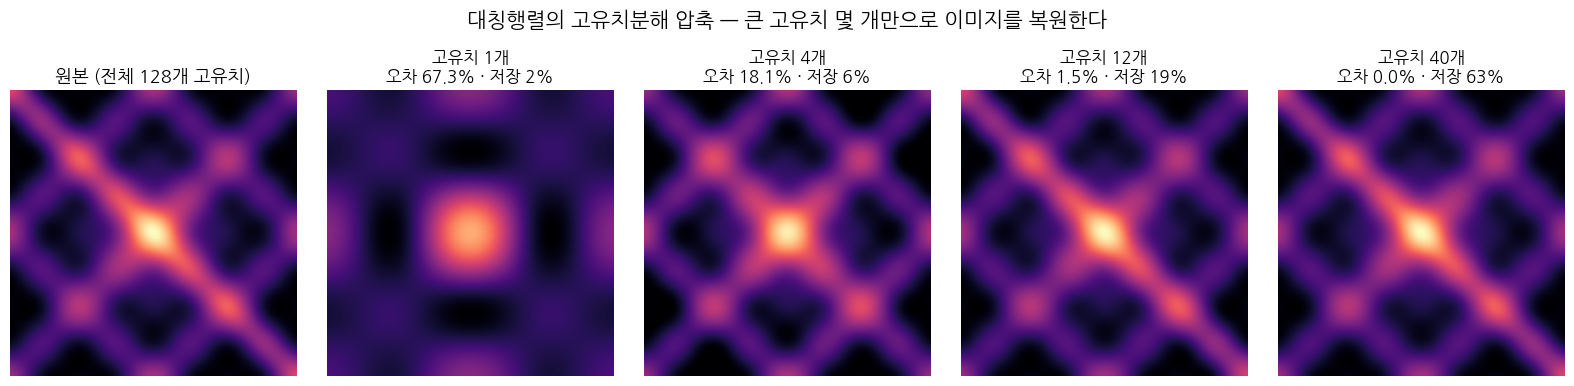

In [13]:
ks = [1, 4, 12, 40]
fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))
vmin, vmax = img.min(), img.max()
axes[0].imshow(img, cmap='magma', vmin=vmin, vmax=vmax)
axes[0].set_title(f'원본 (전체 {n}개 고유치)', fontsize=13)
for ax, k in zip(axes[1:], ks):
    err = np.linalg.norm(img - rank_k(k)) / np.linalg.norm(img)
    comp = 100*(2*k*n + k)/(n*n)
    ax.imshow(rank_k(k), cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(f'고유치 {k}개\n오차 {err*100:.1f}% · 저장 {comp:.0f}%', fontsize=12)
for ax in axes: ax.axis('off')
fig.suptitle('대칭행렬의 고유치분해 압축 — 큰 고유치 몇 개만으로 이미지를 복원한다', fontsize=15, y=1.06)
plt.tight_layout(); plt.show()

고유치 1개로는 중앙의 큰 덩어리만 잡히고, 4개에서 격자 무늬가, 12개에서 거의 원본과 구분되지 않는다(오차 1.5%). 즉 **큰 고유치 몇 개가 이미지의 대부분을 설명**한다.

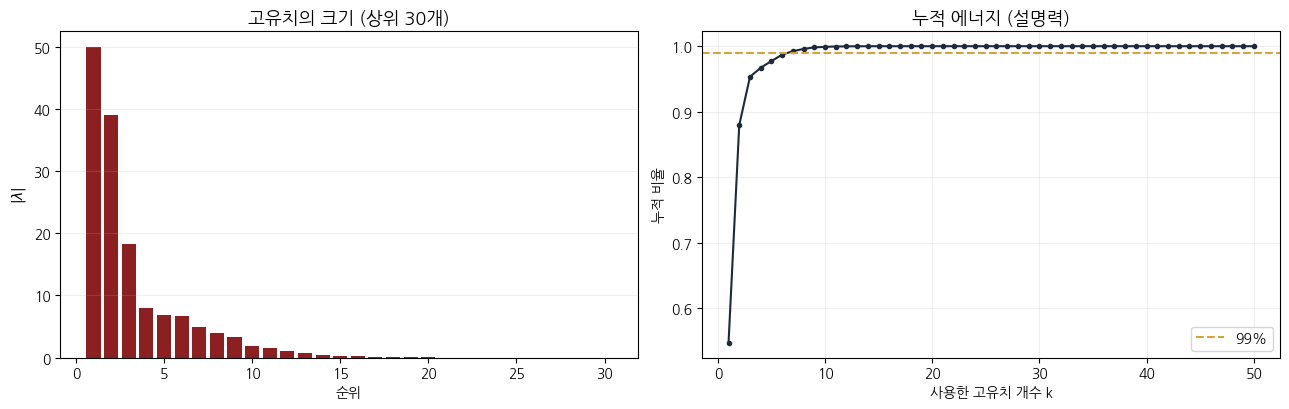

12개로 누적 에너지 = 0.9998


In [14]:
# 고유치 크기와 누적 에너지(설명력)
energy = np.cumsum(w_img**2) / np.sum(w_img**2)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
ax[0].bar(range(1, 31), np.abs(w_img[:30]), color='#8c2020')
ax[0].set_title('고유치의 크기 (상위 30개)', fontsize=13)
ax[0].set_xlabel('순위'); ax[0].set_ylabel(r'$|\lambda|$'); ax[0].grid(alpha=0.2, axis='y')
ax[1].plot(range(1, 51), energy[:50], marker='o', ms=3, color='#1e2a3a')
ax[1].axhline(0.99, ls='--', color='#d4a437', label='99%')
ax[1].set_title('누적 에너지 (설명력)', fontsize=13)
ax[1].set_xlabel('사용한 고유치 개수 k'); ax[1].set_ylabel('누적 비율')
ax[1].legend(); ax[1].grid(alpha=0.2)
plt.tight_layout(); plt.show()
print("12개로 누적 에너지 =", round(energy[11], 4))   # 약 0.9998

## 6. 정리

| 단계 | 식 / 함수 | 뜻 |
|---|---|---|
| 고유치·고유벡터 | `A v = λ v`, `np.linalg.eigh` | 방향 불변, 크기만 λ배 |
| 대칭행렬 | `Q` 정규직교 → `Q⁻¹ = Qᵀ` | 고유벡터가 직교, 정규화하면 직교행렬 |
| 고유치분해 | `A = Q Λ Qᵀ` | 분해 후 되곱하면 원행렬 복원 |
| 스펙트럼 | `A = Σ λᵢ qᵢqᵢᵀ` | 큰 고유치가 큰 골격 |
| 압축 | `A_k = Σ_{i≤k} λᵢ qᵢqᵢᵀ` | 큰 고유치 k개만 → 근사 |

대칭행렬에서는 고유치분해와 **SVD**(특이값 분해)가 일치하며, 일반(직사각) 이미지의 압축은 SVD로 같은 원리를 쓴다. 특이값은 대칭행렬 `AᵀA` 의 고유치의 제곱근이다. 오늘 배운 **전치·행렬곱·역행렬**이 여기서도 그대로 쓰였다 — 직교행렬에서 역행렬이 전치가 된다는 점이 분해를 깔끔하게 만든다.